Steffensen's method: Denominator close to zero at iteration 3


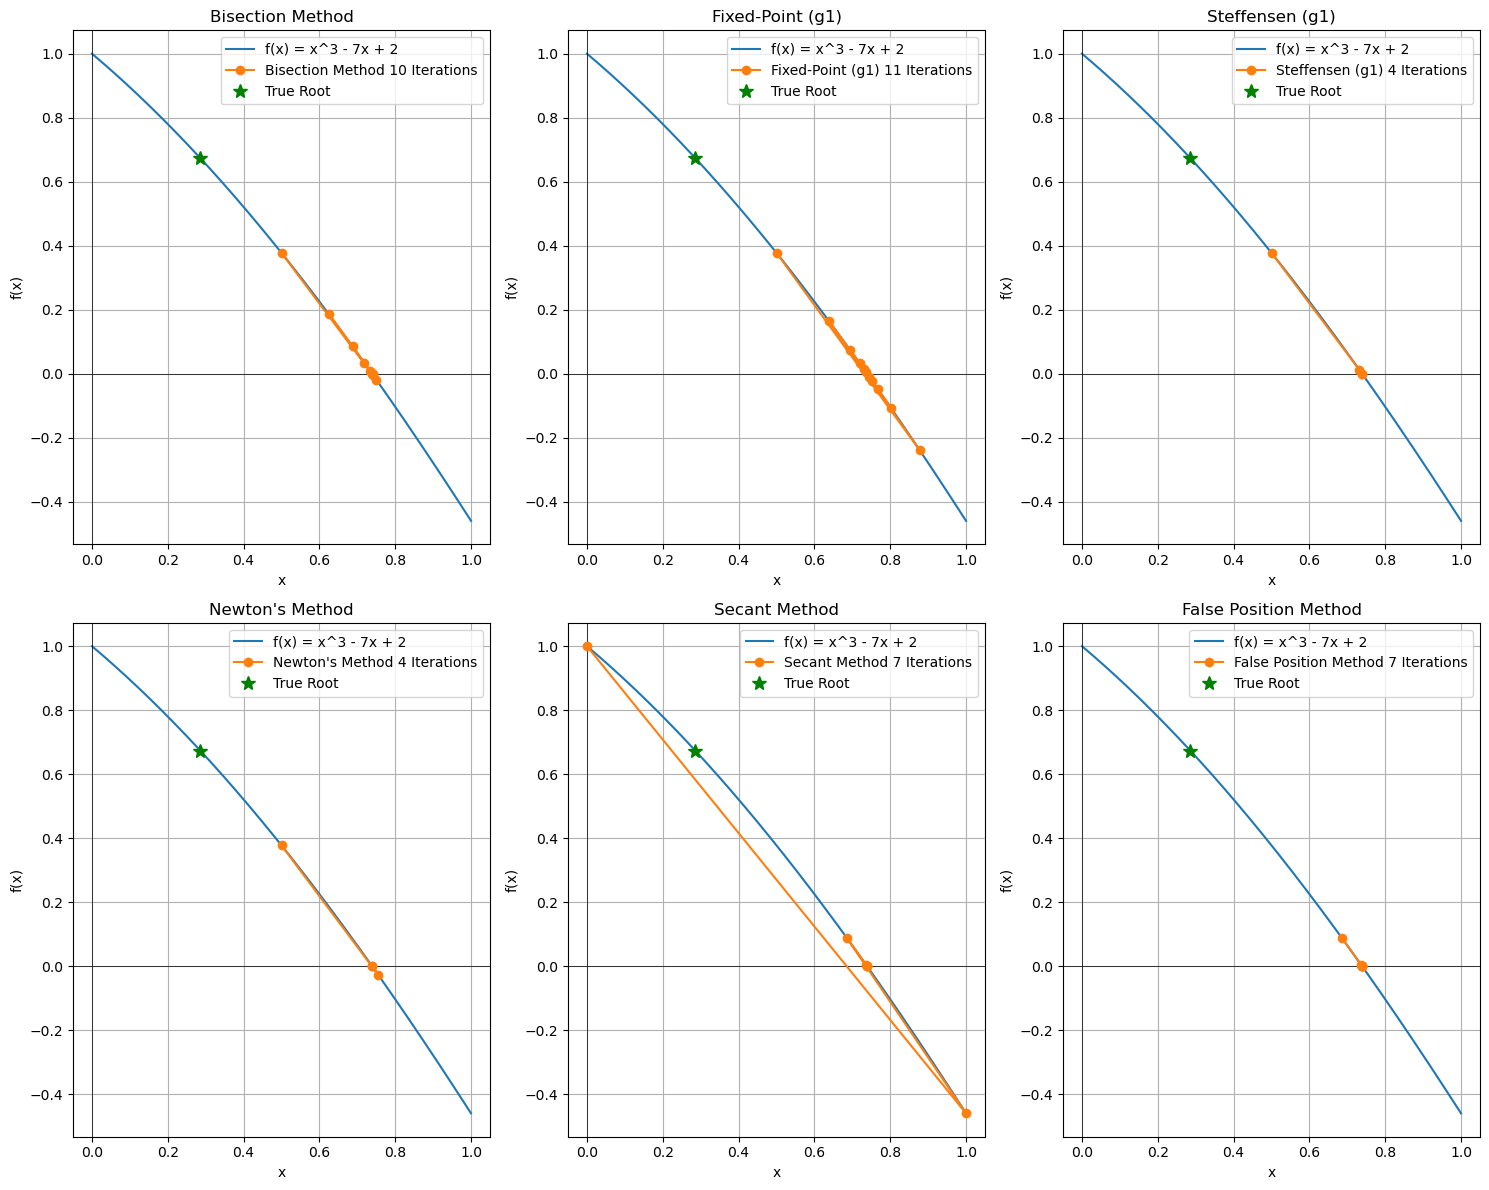

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define a test function and its derivative (for Newton's method)
def f(x):
    # return x**3 - 7*x + 2
    return np.cos(x) - x

def df(x):
    # return 3*x**2 - 7
    return -np.sin(x)-1
# True root (approximately, for visualization)
true_root = 0.2861959900

# --- Root-finding methods (same as before) ---
def bisection(f, a, b, tol=1e-8, max_iter=10):
    iterations = []
    fa = f(a)
    fb = f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("Function must have opposite signs at the endpoints.")
    for i in range(max_iter):
        p = (a + b) / 2
        fp = f(p)
        iterations.append(p)
        if abs(fp) < tol or (b - a) / 2 < tol:
            break
        if np.sign(fa) == np.sign(fp):
            a = p
            fa = fp
        else:
            b = p
            fb = fp
    return iterations

def fixed_point(g, x0, tol=1e-8, max_iter=10):
    iterations = [x0]
    x = x0
    for i in range(max_iter):
        x_new = g(x)
        iterations.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return iterations

def g1(x):
    # return (x**3 + 2) / 7
    return np.cos(x)
def g2(x):
    return np.sqrt((7*x - 2)**(1/3))

def steffensen(g, x0, tol=1e-8, max_iter=10):
    iterations = [x0]
    p_prev = x0
    for i in range(max_iter):
        p1 = g(p_prev)
        p2 = g(p1)
        denominator = p2 - 2 * p1 + p_prev
        if abs(denominator) < 1e-10:  # Avoid division by very small number
            print(f"Steffensen's method: Denominator close to zero at iteration {i}")
            break
        p_next = p_prev - (p1 - p_prev)**2 / denominator
        iterations.append(p_next)
        if abs(p_next - p_prev) < tol:
            print(f"Steffensen's method converged at iteration {i}")
            break
        p_prev = p_next
    return iterations
  

def newton_by_fp(f, df, x0, tol=1e-8, max_iter=10):
    def g(x):
        return x - (f(x)/df(x))
    return fixed_point(g, x0, tol, max_iter)

def newton(f, df, x0, tol=1e-8, max_iter=10):
    iterations = [x0]
    x = x0
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol:
            break
        dfx = df(x)
        if dfx == 0:
            break
        x_new = x - fx / dfx
        iterations.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return iterations

def secant(f, p0, p1, tol=1e-8, max_iter=10):
    iterations = [p0, p1]
    q0 = f(p0)
    q1 = f(p1)
    for i in range(2, max_iter + 2):
        if abs(q1) < tol:
            break
        if abs(q1 - q0) < 1e-8:
            break
        p_new = p1 - q1 * (p1 - p0) / (q1 - q0)
        iterations.append(p_new)
        q_new = f(p_new)
        if abs(q_new) < tol or abs(p_new - p1) < tol:
            break
        p0 = p1
        q0 = q1
        p1 = p_new
        q1 = q_new
    return iterations

def false_position(f, a, b, tol=1e-8, max_iter=10):
    iterations = []
    fa = f(a)
    fb = f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("Function must have opposite signs at the endpoints.")
    for i in range(max_iter):
        p = b - fb * (b - a) / (fb - fa)
        fp = f(p)
        iterations.append(p)
        if abs(fp) < tol or abs(b - a) < tol:
            break
        if np.sign(fa) == np.sign(fp):
            a = p
            fa = fp
        else:
            b = p
            fb = fp
    return iterations

# --- Plotting Function ---
def plot_convergence(ax, x_vals, y_vals, method_name, iterations, true_root, f, extra_plot=None, extra_label=None):
    ax.plot(x_vals, y_vals, label='f(x) = x^3 - 7x + 2')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.plot(iterations, [f(p) for p in iterations], 'o-', label=f'{method_name} {len(iterations)} Iterations')
    ax.plot(true_root, f(true_root), 'g*', markersize=10, label='True Root')
    ax.set_title(method_name)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    ax.grid(True)
    if extra_plot is not None:
        ax.plot(x_vals, extra_plot(x_vals), label=extra_label, linestyle='--')
        ax.legend()

# --- Visualization using the plotting function ---
x_vals = np.linspace(0, 1, 400)
y_vals = f(x_vals)

fig, axes = plt.subplots(2, 3, figsize=(15, 12))

# 1. Bisection Method Plot
a_bisection = 0
b_bisection = 1
try:
    bisection_iterations = bisection(f, a_bisection, b_bisection)
    plot_convergence(axes[0, 0], x_vals, y_vals, 'Bisection Method', bisection_iterations, true_root, f)
except ValueError as e:
    axes[0, 0].set_title(f'Bisection Method: Error - {e}')

# 2. Fixed-Point Iteration Plot (using g1)
x0_fixed_point = 0.5
fixed_point_iterations = fixed_point(g1, x0_fixed_point)
plot_convergence(axes[0, 1], x_vals, y_vals, 'Fixed-Point (g1)', fixed_point_iterations, true_root, f)
# x_fixed = np.linspace(-1, 1, 100)
# y_fixed = g1(x_fixed)
# axes[0, 1].plot(x_fixed, y_fixed, label='g(x) = (x^3 + 2) / 7')
# axes[0, 1].plot(x_fixed, x_fixed, label='y = x', linestyle='--')
# axes[0, 1].plot(fixed_point_iterations, [g1(p) for p in fixed_point_iterations], 'bo-', label='Fixed-Point Iterations')
# axes[0, 1].plot(true_root, g1(true_root), 'g*', markersize=10, label='True Root')
# axes[0, 1].set_title('Fixed-Point Iteration (g1)')
# axes[0, 1].set_xlabel('x')
# axes[0, 1].set_ylabel('g(x) or y')
# axes[0, 1].legend()
# axes[0, 1].grid(True)

# steffensen's method
steffensen_iterations = steffensen(g1,x0_fixed_point)
plot_convergence(axes[0, 2], x_vals, y_vals, 'Steffensen (g1)', steffensen_iterations, true_root, f)


# 3. Newton's Method Plot
x0_newton = 0.5
newton_iterations = newton(f, df, x0_newton)
plot_convergence(axes[1, 0], x_vals, y_vals, "Newton's Method", newton_iterations, true_root, f)

# 4. Secant Method Plot
p0_secant = 0
p1_secant = 1
secant_iterations = secant(f, p0_secant, p1_secant)
plot_convergence(axes[1, 1], x_vals, y_vals, 'Secant Method', secant_iterations, true_root, f)

# 5. False Position Method Plot
a_false_position = 0
b_false_position = 1
try:
    false_position_iterations = false_position(f, a_false_position, b_false_position)
    plot_convergence(axes[1, 2], x_vals, y_vals, 'False Position Method', false_position_iterations, true_root, f)
except ValueError as e:
    axes[1, 2].set_title(f'False Position Method: Error - {e}')

# Remove the empty subplot
#fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

In [26]:
newton(f, df, x0_newton)

[0.5, 0.28, 0.2891579943235572, 0.28916854643399825]

In [27]:
newton_by_fp(f, df, x0_newton)

[0.5, 0.28, 0.2891579943235572, 0.28916854643399825, 0.2891685464483099]